<a href="https://colab.research.google.com/github/Valrite/Digital-Image-Processing-Labs/blob/main/Lab8/Lab8.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h3> Pg 8: Perform edge detection and region-based segmentation in an image</h3>

In [ ]:
#import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt


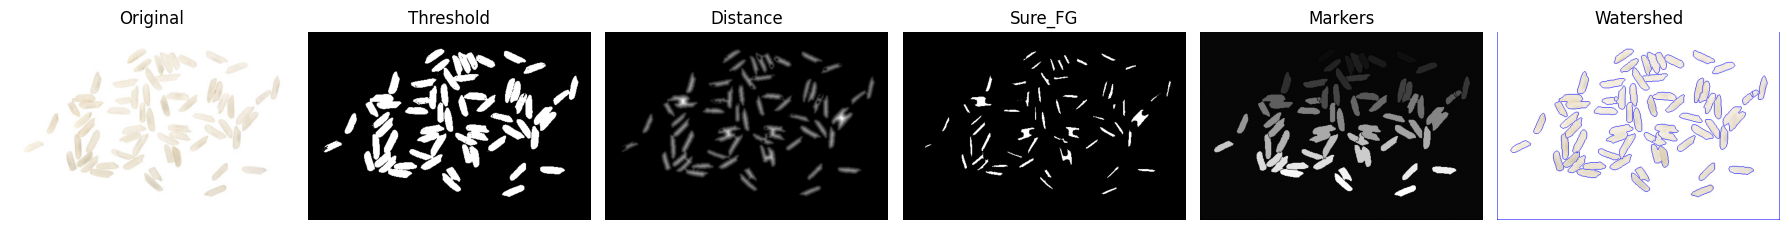

In [ ]:
img = cv2.imread('rice.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# ---- Binary segmentation (objects vs background) ----
# Objects should be WHITE
_, thresh = cv2.threshold(
gray, 0, 255,
cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)
# ---- Sure background ----
kernel = np.ones((3,3), np.uint8)
sure_bg = cv2.dilate(thresh, kernel, iterations=3)
# ---- Distance transform - compute distance to nearest '0' ----
dist = cv2.distanceTransform(thresh, cv2.DIST_L2, 5)
# ---- extract foreground markers (SMALL seeds to flood the basins with) ----
_, sure_fg = cv2.threshold(dist, 0.4 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
# ---- Unknown region ----
unknown = cv2.subtract(sure_bg, sure_fg) # all unknown regions will be marked␣↪255
# ---- Connected components ----
num_markers, markers = cv2.connectedComponents(sure_fg)
#Connected components return markers as 0 → background, 1 → object A, 2 →␣↪object B
# Watershed assumes 0 → unknown region 1 → background 2 → object A
# to meet assumptions of watershed,
markers = markers + 1
# Mark unknown region as 0
markers[unknown == 255] = 0
# ---- Watershed on ORIGINAL IMAGE ----
markers_ws = cv2.watershed(img, markers)
# ---- Overlay boundaries ----
result = img.copy()
result[markers_ws == -1] = [255, 0, 0]
# ---- Visualization ----
fig, ax = plt.subplots(1,6,figsize=(18,5))
titles = ["Original","Threshold","Distance","Sure_FG","Markers","Watershed"]
images = [
cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
thresh,
dist,
sure_fg.astype(np.float32),
markers.astype(np.float32),
cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
]
for i in range(len(images)):
  ax[i].imshow(images[i], cmap='gray')
  ax[i].set_title(titles[i])
  ax[i].axis("off")
plt.tight_layout()
plt.show()

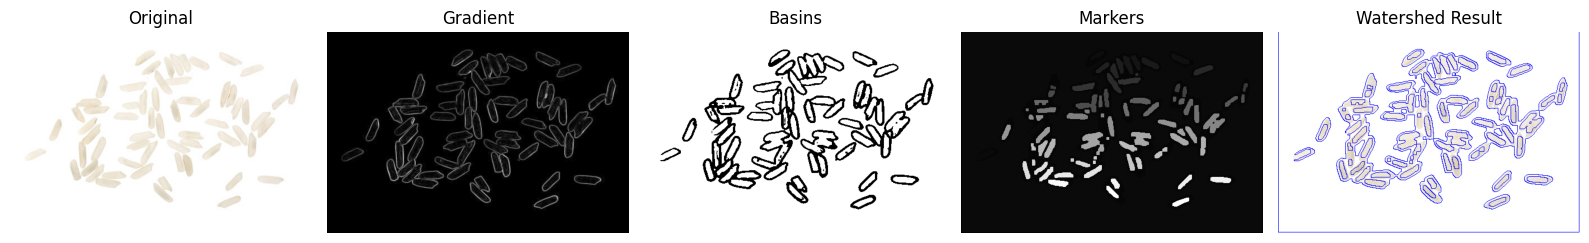

In [ ]:
# read image, convert to grayscale
img =  cv2.imread("rice.jpg")
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

# Compute Gradient magnitude using sobel operator
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sobel_x, sobel_y)
gradient = cv2.convertScaleAbs(sobel_mag)

# Smoothen gradient using Gaussian Blur
gradient_blur = cv2.GaussianBlur(gradient,(5,5),0)

# Threshold gradient to obtain binary image
_, grad_thresh =  cv2.threshold(gradient_blur,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Invert for basins
basins = cv2.bitwise_not(grad_thresh) #or  255 - grad_thresh


# Marker extraction
kernel = np.ones((3,3),np.uint8)
markers_img = cv2.morphologyEx(basins,cv2.MORPH_OPEN,kernel,iterations=2)
num_components, markers = cv2.connectedComponents(markers_img) #area in no. of pixels + bounding box + centroid-->cv2.connectedComponentsWithStats

#Connected components return markers as 0 → background, 1 → object A, 2 → object B
# Watershed assumes 0 → unknown region 1 → background 2 → object A
# to meet assumptions of watershed,
markers = markers + 1

# Watershed on gradient image
gradient_color = cv2.cvtColor(gradient_blur,cv2.COLOR_GRAY2BGR)

markers_ws = cv2.watershed(gradient_color,markers)

# ---- Extract boundary mask ----
boundary = np.zeros_like(markers_ws, dtype=np.uint8)
boundary[:-1,:] |= (markers_ws[:-1,:] != markers_ws[1:,:])
boundary[:,:-1] |= (markers_ws[:,:-1] != markers_ws[:,1:])
boundary = boundary.astype(np.uint8) * 255


# ---- Overlay on original image ----
result = img.copy()
result[boundary == 255] = [255,0,0]

# Visualization
fig, ax= plt.subplots(1,5,figsize=(16,5))

titles = ["Original","Gradient","Basins","Markers", "Watershed Result"]

images = [
cv2.cvtColor(img,cv2.COLOR_BGR2RGB),
gradient,
basins,
markers.astype(np.float32),
cv2.cvtColor(result,cv2.COLOR_BGR2RGB)
]

for i in range(len(images)):
    ax[i].imshow(images[i], cmap='gray')
    ax[i].set_title(titles[i])
    ax[i].axis("off")

plt.tight_layout()
plt.show()

##### <h1>Watershed Segmentation using Gradient Topography</h1>

<p>
The watershed algorithm interprets an image as a <b>topographic surface</b>.
Pixel intensities represent terrain elevation, where low values form valleys
and high values form ridges. Water is conceptually poured into the valleys,
and the locations where water from different valleys meets become the
<b>watershed boundaries</b>.
</p>

<h2>Step 1: Original Image</h2>

<p>
The input image is first loaded and converted to grayscale. Grayscale
simplifies processing because the watershed algorithm operates on
single-channel intensity values.
</p>


<p>
This image contains several objects (sickle cells) that we want to separate
using watershed segmentation.
</p>


<h2>Step 2: Gradient Magnitude Computation</h2>

<p>
The gradient magnitude of the image is computed using the Sobel operator.
The gradient highlights locations where the intensity changes rapidly,
which usually correspond to object boundaries.
</p>


<p>
Mathematically, the gradient magnitude is computed as:
</p>

<p>
|∇I| = √(Gx² + Gy²)
</p>

<p>
where <b>Gx</b> and <b>Gy</b> are horizontal and vertical gradients.
High gradient values indicate strong edges.
</p>


<h2>Step 3: Gradient Smoothing</h2>

<p>
The gradient image is smoothed using a Gaussian filter. This removes
small fluctuations and noise that could otherwise lead to excessive
segmentation.
</p>


<p>
Smoothing produces a cleaner topographic surface where meaningful
basins can be identified.
</p>


<h2>Step 4: Thresholding the Gradient</h2>

<p>
Otsu's thresholding method is applied to convert the gradient image
into a binary image. This separates strong edges from weaker regions.
</p>


<p>
The thresholded image highlights regions of strong gradient,
which correspond to likely object boundaries.
</p>


<h2>Step 5: Basin Formation</h2>

<p>
The binary gradient image is inverted so that the non-edge regions
become basins. These basins correspond to relatively uniform regions
in the above image.
These basins serve as the starting regions for the watershed flooding process.
</p>


<h2>Step 6: Marker Extraction</h2>

<p>
Morphological opening is applied to remove small noise regions
and clean the basin image. Connected component labeling is then used
to assign a unique marker label to each basin.
</p>


<p>
Each marker represents a region from which water will begin to flood.
These markers guide the watershed algorithm.
</p>


<h2>Step 7: Watershed Flooding</h2>

<p>
The watershed algorithm is applied to the gradient image using the
extracted markers as initial seeds. Conceptually, water floods
from each marker region simultaneously. When water from two
different basins meets, a boundary is formed.
</p>

<p>
In the implementation, these boundary pixels are labeled with the
value <b>-1</b>.
</p>

<h2>Step 8: Final Segmentation Result</h2>

<p>
The thickened watershed boundaries are overlaid on the original image.
These boundaries indicate where different segmented regions meet.
</p>




